In [1]:
# =============================================================================
# Part 1: 数据准备 
# =============================================================================
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import os

# --- 1. 加载原始数据 --
S = np.load('results_32x32_gpu.npy')
# S 的形状是 (H, W, Nt, B)，即 (高度, 宽度, 时间步数, 样本数)
H, W, Nt, B = S.shape 
print(f"原始数据形状: 长度={H}, 宽度={W}, 时间步={Nt}, 模拟样本数={B}")
total_time = 3.0

# --- 2. 按指定的 100 / 25 / 25 数量划分模拟样本 ---

# 定义划分数量
train_count = 100
val_count = 25
sim_indices = np.arange(B)
# 获取划分后的模拟样本索引
train_sim_indices = sim_indices[:train_count]
val_sim_indices = sim_indices[train_count : train_count + val_count]
test_sim_indices = sim_indices[train_count + val_count:]

# 根据索引创建数据子集
S_train = S[:, :, :, train_sim_indices]
S_val = S[:, :, :, val_sim_indices]
S_test = S[:, :, :, test_sim_indices]

print(f"模拟样本划分: {len(train_sim_indices)} (训练) / {len(val_sim_indices)} (验证) / {len(test_sim_indices)} (测试)")


# --- 3. 为【训练集】准备张量  ---
print("\n--- 正在处理训练集... ---")
H, W, Nt, B_train = S_train.shape
time_points = np.linspace(0, total_time, Nt, dtype=np.float32)
Y_data_train = S_train[:, :, 1:, :]
initial_conditions_train = S_train[:, :, 0:1, :]
X_data_u0_train = np.repeat(initial_conditions_train, Nt - 1, axis=2)
target_times = time_points[1:]
time_channel_template = target_times.reshape(1, 1, -1, 1)
X_data_time_train = np.broadcast_to(time_channel_template, (H, W, Nt - 1, B_train))
X_data_combined_train = np.stack([X_data_u0_train, X_data_time_train], axis=-1)
X_reshaped_train = X_data_combined_train.transpose(0, 1, 3, 2, 4).reshape(H, W, -1, 2)
Y_reshaped_train = Y_data_train.transpose(0, 1, 3, 2).reshape(H, W, -1)
X_train_final = np.transpose(X_reshaped_train, (2, 3, 0, 1))
Y_train_final = np.expand_dims(np.transpose(Y_reshaped_train, (2, 0, 1)), axis=1)
X_train, Y_train = torch.from_numpy(X_train_final), torch.from_numpy(Y_train_final).float()
print(f"训练集最终形状: X={X_train.shape}, Y={Y_train.shape}")


# --- 4. 为【验证集】准备张量 ---
print("\n--- 正在处理验证集... ---")
H, W, Nt, B_val = S_val.shape
time_points = np.linspace(0, total_time, Nt, dtype=np.float32)
Y_data_val = S_val[:, :, 1:, :]
initial_conditions_val = S_val[:, :, 0:1, :]
X_data_u0_val = np.repeat(initial_conditions_val, Nt - 1, axis=2)
target_times = time_points[1:]
time_channel_template = target_times.reshape(1, 1, -1, 1)
X_data_time_val = np.broadcast_to(time_channel_template, (H, W, Nt - 1, B_val))
X_data_combined_val = np.stack([X_data_u0_val, X_data_time_val], axis=-1)
X_reshaped_val = X_data_combined_val.transpose(0, 1, 3, 2, 4).reshape(H, W, -1, 2)
Y_reshaped_val = Y_data_val.transpose(0, 1, 3, 2).reshape(H, W, -1)
X_val_final = np.transpose(X_reshaped_val, (2, 3, 0, 1))
Y_val_final = np.expand_dims(np.transpose(Y_reshaped_val, (2, 0, 1)), axis=1)
X_val, Y_val = torch.from_numpy(X_val_final), torch.from_numpy(Y_val_final).float()
print(f"验证集最终形状: X={X_val.shape}, Y={Y_val.shape}")


# --- 5. 为【测试集】准备张量  ---
print("\n--- 正在处理测试集... ---")
H, W, Nt, B_test = S_test.shape
time_points = np.linspace(0, total_time, Nt, dtype=np.float32)
Y_data_test = S_test[:, :, 1:, :]
initial_conditions_test = S_test[:, :, 0:1, :]
X_data_u0_test = np.repeat(initial_conditions_test, Nt - 1, axis=2)
target_times = time_points[1:]
time_channel_template = target_times.reshape(1, 1, -1, 1)
X_data_time_test = np.broadcast_to(time_channel_template, (H, W, Nt - 1, B_test))
X_data_combined_test = np.stack([X_data_u0_test, X_data_time_test], axis=-1)
X_reshaped_test = X_data_combined_test.transpose(0, 1, 3, 2, 4).reshape(H, W, -1, 2)
Y_reshaped_test = Y_data_test.transpose(0, 1, 3, 2).reshape(H, W, -1)
X_test_final = np.transpose(X_reshaped_test, (2, 3, 0, 1))
Y_test_final = np.expand_dims(np.transpose(Y_reshaped_test, (2, 0, 1)), axis=1)
X_test, Y_test = torch.from_numpy(X_test_final), torch.from_numpy(Y_test_final).float()
print(f"测试集最终形状: X={X_test.shape}, Y={Y_test.shape}")


# --- 6. 创建最终的 Dataset 和 DataLoader ---
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test, Y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



原始数据形状: 长度=32, 宽度=32, 时间步=301, 模拟样本数=150
模拟样本划分: 100 (训练) / 25 (验证) / 25 (测试)

--- 正在处理训练集... ---
训练集最终形状: X=torch.Size([30000, 2, 32, 32]), Y=torch.Size([30000, 1, 32, 32])

--- 正在处理验证集... ---
验证集最终形状: X=torch.Size([7500, 2, 32, 32]), Y=torch.Size([7500, 1, 32, 32])

--- 正在处理测试集... ---
测试集最终形状: X=torch.Size([7500, 2, 32, 32]), Y=torch.Size([7500, 1, 32, 32])


开始训练 FNO 模型，设备: cuda
Epoch 1/100, 训练损失: 0.0013588402429908658, 验证损失: 3.779990580924432e-05
  -> 验证损失降低，模型已保存。
Epoch 2/100, 训练损失: 1.8662158345444567e-05, 验证损失: 2.8186383911754276e-05
  -> 验证损失降低，模型已保存。
Epoch 3/100, 训练损失: 1.0752939539061253e-05, 验证损失: 7.3447417812762285e-06
  -> 验证损失降低，模型已保存。
Epoch 4/100, 训练损失: 8.324174246626693e-06, 验证损失: 6.6411787217429405e-06
  -> 验证损失降低，模型已保存。
Epoch 5/100, 训练损失: 8.360118781366958e-06, 验证损失: 1.8724571611405198e-05
  -> 验证损失未提升。连续未提升次数: 1/7
Epoch 6/100, 训练损失: 7.093665731636433e-06, 验证损失: 7.0539665702106785e-06
  -> 验证损失未提升。连续未提升次数: 2/7
Epoch 7/100, 训练损失: 8.706986031570415e-06, 验证损失: 1.690495817888019e-05
  -> 验证损失未提升。连续未提升次数: 3/7
Epoch 8/100, 训练损失: 4.927316875692457e-06, 验证损失: 5.59580207683381e-06
  -> 验证损失降低，模型已保存。
Epoch 9/100, 训练损失: 5.180778170402586e-06, 验证损失: 8.460679875027428e-06
  -> 验证损失未提升。连续未提升次数: 1/7
Epoch 10/100, 训练损失: 7.512820515929751e-06, 验证损失: 3.5254616041244952e-06
  -> 验证损失降低，模型已保存。
Epoch 11/100, 训练损失: 3.2123323865568086e-06, 验证损失: 2.8

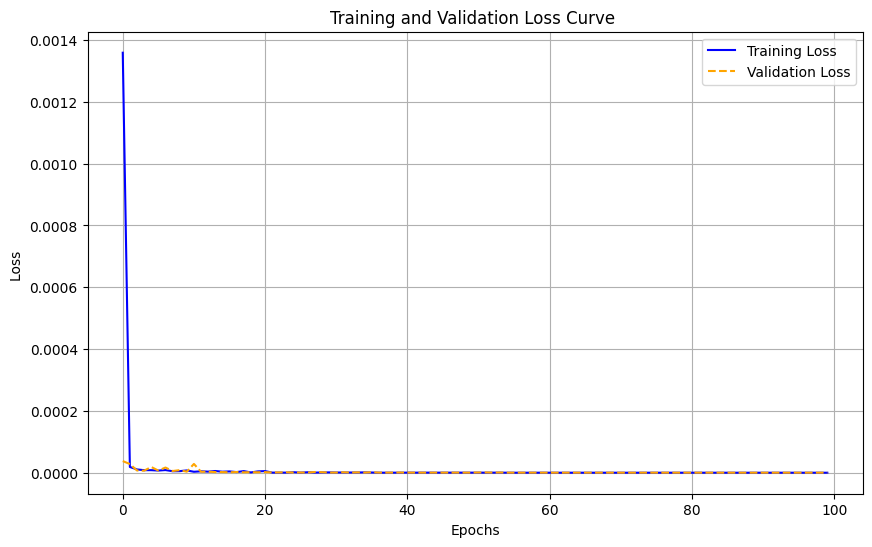

In [3]:
# =============================================================================
# Part 2: 模型定义与训练
# =============================================================================
from neuralop.models import FNO
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time 
# --- 1. 定义模型 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = FNO(
    n_modes=(12, 12),
    hidden_channels=64,
    in_channels=2,
    out_channels=1
).to(device)

# --- 2. 定义损失函数、优化器和训练循环 ---
loss_mse = torch.nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=4)
epochs = 100
patience = 7 
epochs_no_improve = 0
train_losses, val_losses = [], []
best_val_loss = float('inf')
output_dir = 'model_32x32_12'
if not os.path.exists(output_dir): os.makedirs(output_dir)
full_save_path = os.path.join(output_dir, 'best_fno_model.pth')

# --- 3. 训练循环 ---
print(f"开始训练 FNO 模型，设备: {device}")
start_time = time.time()
for epoch in range(epochs):
    model.train()
    current_train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = loss_mse(out.squeeze(), y.squeeze())
        loss.backward()
        optimizer.step()
        current_train_loss += loss.item()
    
    avg_train_loss = current_train_loss / len(train_loader)
    train_losses.append(avg_train_loss) 

    model.eval()
    current_val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = loss_mse(out.squeeze(), y.squeeze())
            current_val_loss += loss.item()
            
    avg_val_loss = current_val_loss / len(val_loader)

     # 根据验证损失调整学习率
    scheduler.step(avg_val_loss)
    val_losses.append(avg_val_loss) 

    print(f"Epoch {epoch+1}/{epochs}, 训练损失: {avg_train_loss}, 验证损失: {avg_val_loss}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), full_save_path)
        print(f"  -> 验证损失降低，模型已保存。")
        epochs_no_improve = 0 
    else:
        epochs_no_improve += 1 
        print(f"  -> 验证损失未提升。连续未提升次数: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print(f"\n验证损失连续 {patience} 个epoch未提升，触发早停！")
        break 
end_time = time.time()
print("训练完成！")
# --- 计算并打印训练耗时 ---
total_training_seconds = end_time - start_time
total_training_minutes = total_training_seconds / 60
print(f"\n总训练耗时: {total_training_seconds:.2f} 秒 ({total_training_minutes:.2f} 分钟)")
# --- 4. 绘制并保存损失曲线  ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange', linestyle='--')
plt.title('Training and Validation Loss Curve ')
plt.xlabel('Epochs')
plt.ylabel('Loss ')
plt.legend()
plt.grid(True)

figure_save_path = os.path.join(output_dir, 'loss_curve_time_conditioned.png')
plt.savefig(figure_save_path)
print(f"损失曲线图已保存至: {figure_save_path}")
plt.show()

/tmp/ipykernel_2258/549184985.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


模型 model_32x32_12/best_fno_model.pth 加载成功，评估设备: cuda

--- 正在测试集上进行量化评估... ---
在整个测试集上的平均 MSE 损失: 0.00000013

--- 开始对测试样本 130 进行直接预测可视化 ---

已确定全局色条范围: Vmin=-0.0013, Vmax=0.2435
已确定全局误差色条范围: Vmax_error=0.0020

--- 正在绘制时刻 t = 0.1000s 的图像 ---
  平均绝对误差: 0.000319
  最大绝对误差: 0.001999


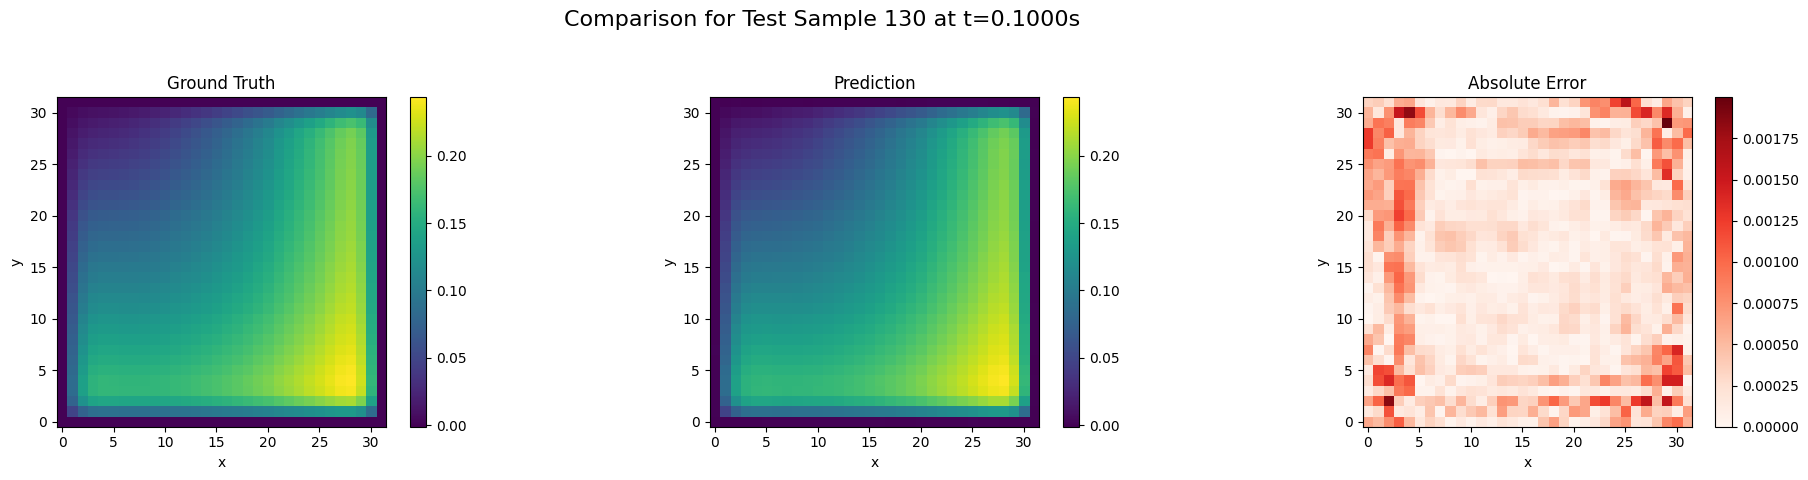

--- 正在绘制时刻 t = 1.0000s 的图像 ---
  平均绝对误差: 0.000240
  最大绝对误差: 0.000849


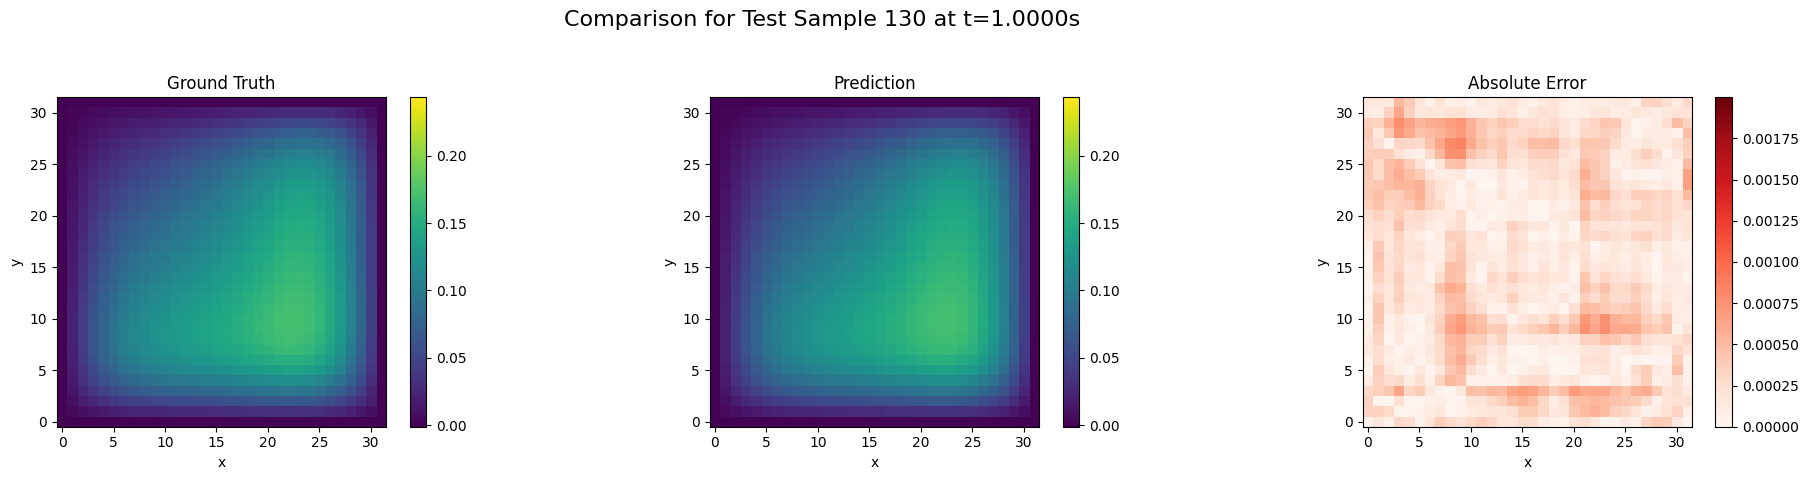

--- 正在绘制时刻 t = 2.0000s 的图像 ---
  平均绝对误差: 0.000169
  最大绝对误差: 0.000669


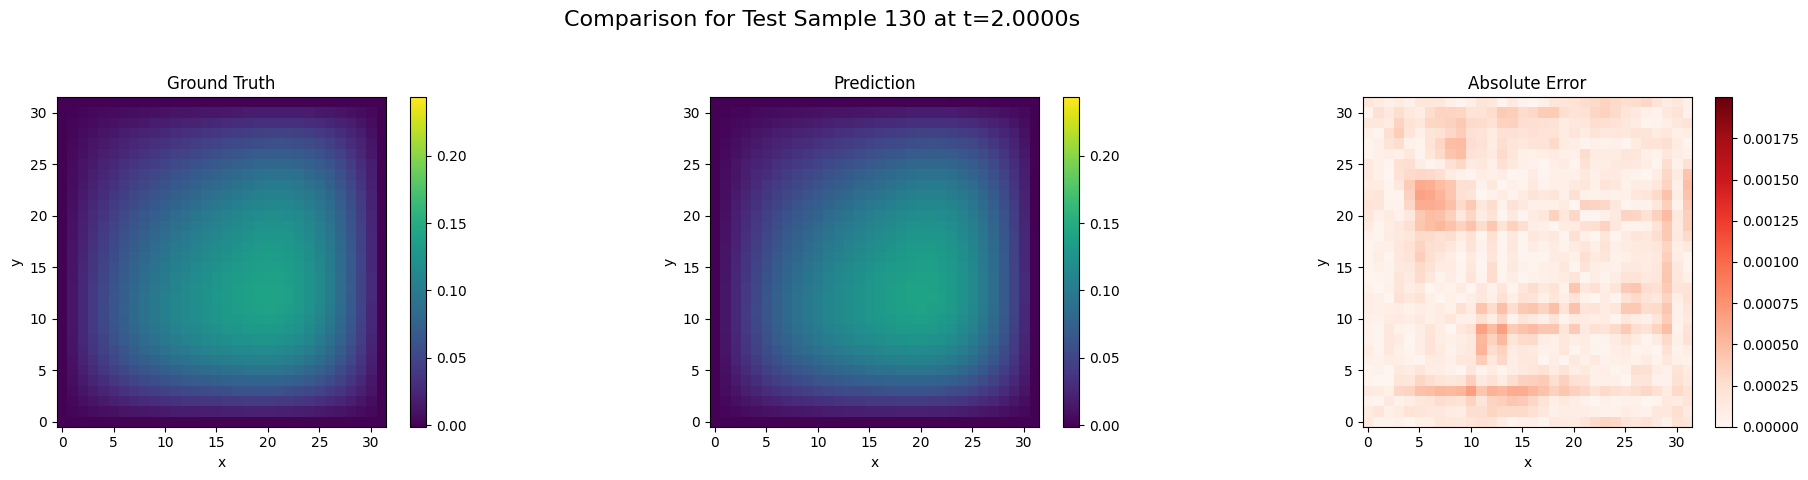

--- 正在绘制时刻 t = 3.0000s 的图像 ---
  平均绝对误差: 0.000174
  最大绝对误差: 0.000704


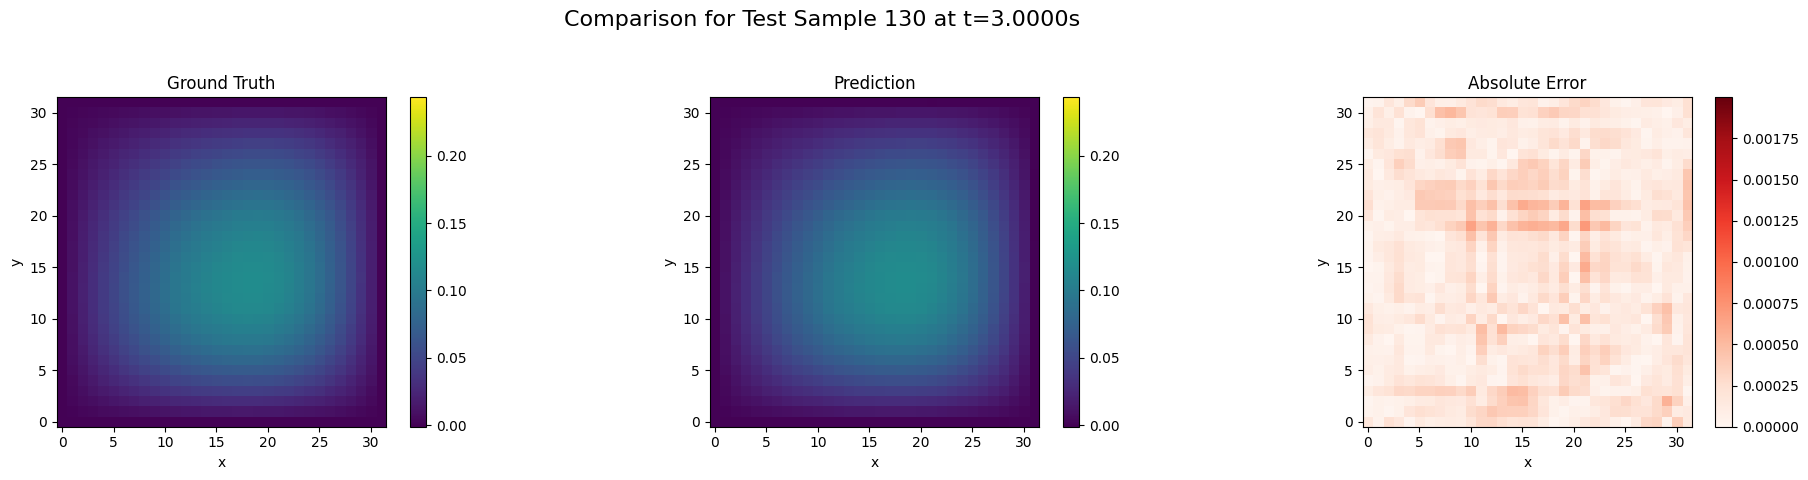

In [5]:
# =============================================================================
# Part 3: 模型评估与可视化 
# =============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from neuralop.models import FNO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 1. 加载训练好的模型 ---
model = FNO(n_modes=(12, 12), hidden_channels=64, in_channels=2, out_channels=1)
model_path = 'model_32x32_12/best_fno_model.pth'
if not os.path.exists(model_path):
    print(f"错误: 找不到模型文件 {model_path}。请先运行训练代码。")
    exit()
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()
print(f"模型 {model_path} 加载成功，评估设备: {device}")


# --- 2. 在【整个测试集】上进行量化评估 ---
print("\n--- 正在测试集上进行量化评估... ---")
loss_mse = torch.nn.MSELoss()
test_loss = 0.0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = loss_mse(out, y)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
print(f"在整个测试集上的平均 MSE 损失: {avg_test_loss:.8f}")


# --- 3. 在【测试集的单个样本】上进行可视化分析 ---

train_count = 100
val_count = 25
test_start_index = train_count + val_count

# 加载原始数据
S = np.load('results_32x32_gpu.npy')
H, W, Nt, B = S.shape
total_time = 3.0
time_points = np.linspace(0, total_time, Nt, dtype=np.float32)

# 定义辅助函数
def predict_at_time(model, initial_condition_np, target_time):
    model.eval()
    with torch.no_grad():
        u0_tensor = torch.from_numpy(initial_condition_np).float().unsqueeze(0).unsqueeze(0).to(device)
        H, W = initial_condition_np.shape
        time_tensor = torch.full((1, 1, H, W), float(target_time), device=device)
        model_input = torch.cat([u0_tensor, time_tensor], dim=1)
        prediction = model(model_input)
        return prediction.squeeze().cpu().numpy()

def calculate_errors(prediction, ground_truth):
    if isinstance(prediction, np.ndarray): prediction = torch.from_numpy(prediction)
    if isinstance(ground_truth, np.ndarray): ground_truth = torch.from_numpy(ground_truth)
    abs_error = torch.abs(prediction - ground_truth)
    return {
        "mean_absolute": torch.mean(abs_error).item(),
        "max_absolute": torch.max(abs_error).item(),
        "abs_error_map": abs_error.numpy()
    }


def plot_comparison(ground_truth, prediction, abs_error_map, time_val, sample_idx, vmin, vmax, error_vmax):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Comparison for Test Sample {sample_idx} at t={time_val:.4f}s', fontsize=16)
    
    # 使用传入的全局 vmin 和 vmax
    im1 = axes[0].imshow(ground_truth, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
    axes[0].set_title(f'Ground Truth'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    im2 = axes[1].imshow(prediction, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
    axes[1].set_title(f'Prediction'); axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    # 误差图使用独立的、但同样是全局统一的色条
    im3 = axes[2].imshow(abs_error_map, vmin=0, vmax=error_vmax, origin='lower', cmap='Reds')
    axes[2].set_title(f'Absolute Error'); axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()


# --- 主执行流程 ---
# 选择一个测试集中的样本进行分析
sample_offset = 5
sample_index_in_S = test_start_index + sample_offset

# 提取该样本的初始条件和完整的时间序列作为真实值
initial_condition = S[:, :, 0, sample_index_in_S]
ground_truth_series = S[:, :, :, sample_index_in_S]

# 定义要分析和可视化的时间点
times_to_analyze = [0.1, 1.0, 2.0, 3.0]

print(f"\n--- 开始对测试样本 {sample_index_in_S} 进行直接预测可视化 ---")


all_predictions = []
all_gt_slices = []
all_error_maps = []

for t_val in times_to_analyze:
    predicted_slice = predict_at_time(model, initial_condition, t_val)
    time_idx = np.argmin(np.abs(time_points - t_val))
    gt_slice = ground_truth_series[:, :, time_idx]
    
    all_predictions.append(predicted_slice)
    all_gt_slices.append(gt_slice)

    error_dict = calculate_errors(predicted_slice, gt_slice)
    all_error_maps.append(error_dict['abs_error_map'])

# 将列表转换为Numpy数组以便计算 min/max
all_predictions_np = np.stack(all_predictions)
all_gt_slices_np = np.stack(all_gt_slices)
all_error_maps_np = np.stack(all_error_maps)

# 计算全局的 vmin 和 vmax
global_vmin = min(all_predictions_np.min(), all_gt_slices_np.min())
global_vmax = max(all_predictions_np.max(), all_gt_slices_np.max())
global_error_vmax = all_error_maps_np.max()

print(f"\n已确定全局色条范围: Vmin={global_vmin:.4f}, Vmax={global_vmax:.4f}")
print(f"已确定全局误差色条范围: Vmax_error={global_error_vmax:.4f}\n")


for i, t_val in enumerate(times_to_analyze):
    print(f"--- 正在绘制时刻 t = {t_val:.4f}s 的图像 ---")
    
    predicted_slice = all_predictions[i]
    gt_slice = all_gt_slices[i]
    error_map = all_error_maps[i]

    mean_abs_err = np.mean(error_map)
    max_abs_err = np.max(error_map)
    
    print(f"  平均绝对误差: {mean_abs_err:.6f}")
    print(f"  最大绝对误差: {max_abs_err:.6f}")

    plot_comparison(
        gt_slice, 
        predicted_slice, 
        error_map, 
        t_val, 
        sample_index_in_S,
        vmin=global_vmin,
        vmax=global_vmax,
        error_vmax=global_error_vmax
    )